In [1]:
%pip install tqdm -q

Note: you may need to restart the kernel to use updated packages.


# Import all libraries we will need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Read the files with pandas

In [3]:
# Load the CSV files into pandas DataFrames
df_stores = pd.read_csv('/Users/dianaterraza/Desktop/Data/stores.csv')
df_items = pd.read_csv('/Users/dianaterraza/Desktop/Data/items.csv')
df_transactions = pd.read_csv('/Users/dianaterraza/Desktop/Data/transactions.csv')
df_oil = pd.read_csv('/Users/dianaterraza/Desktop/Data/oil.csv')
df_holidays_events = pd.read_csv('/Users/dianaterraza/Desktop/Data/holidays_events.csv')
df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')
df_test = pd.read_csv('/Users/dianaterraza/Desktop/Data/test.csv')

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_2290/2255240867.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')


In [4]:
# Let's filter the data for one store and one item to keep it simple
store_ids = [1]
item_ids = [96995]
#Select data January-March 2014 period
start_date = '2014-01-01'
end_date = '2014-03-31'


# Initialize an empty list to hold filtered chunks
filtered_chunks = []

# Define the chunk size (number of rows per chunk)
chunk_size = 10 ** 6  # Adjust based on your system's memory capacity

# Read the CSV file in chunks
for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):
    # Filter the chunk for the desired store IDs
    chunk_filtered = chunk[(chunk['store_nbr'].isin(store_ids)) &
                            (chunk['date'] >= start_date) &
                            (chunk['date'] <= end_date)]
    # Append the filtered chunk to the list
    filtered_chunks.append(chunk_filtered)
    # Optional: Delete the chunk to free up memory
    del chunk

# Concatenate all filtered chunks into a single DataFrame
df_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Clean up to free memory
del filtered_chunks

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_2290/3230739008.py:16: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):


# Prepare data

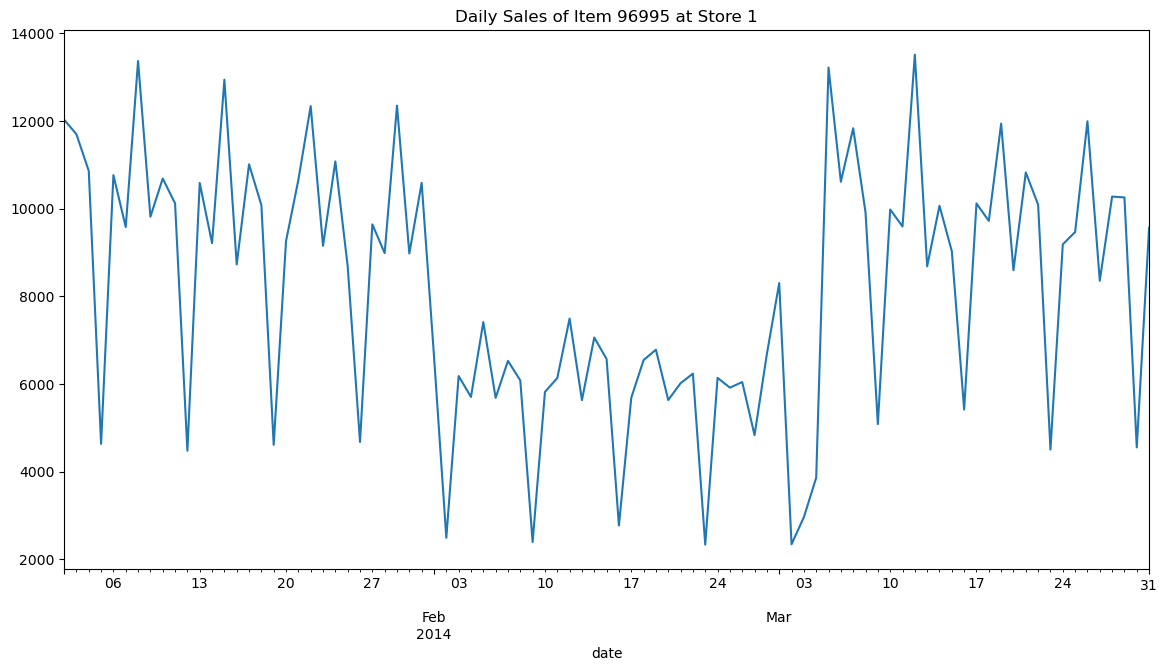

In [5]:
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Group by date and aggregate sales
df_filtered = df_filtered.groupby('date').sum()['unit_sales'].reset_index()

# Fill missing dates with zero sales
df_filtered.set_index('date', inplace=True)
df_filtered = df_filtered.asfreq('D').fillna(0)

# Visualize sales data
plt.figure(figsize=(14, 7))
df_filtered['unit_sales'].plot()
plt.title('Daily Sales of Item 96995 at Store 1')
plt.show()

# Preprocessing the Data for LSTM

In [6]:
# Normalize the data using Min-Max scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_filtered['unit_sales'] = scaler.fit_transform(df_filtered[['unit_sales']])

# Create sequences of data for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Set sequence length (e.g., past 30 days of sales)
seq_length = 30

# Create sequences
data = df_filtered['unit_sales'].values
X, y = create_sequences(data, seq_length)

# Split into training and testing sets (80% training, 20% testing)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape the data to be [samples, time steps, features] for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM model

In [7]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2316 - val_loss: 0.3683
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.2216 - val_loss: 0.3505
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.2117 - val_loss: 0.3322
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1986 - val_loss: 0.3125
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1856 - val_loss: 0.2926
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1763 - val_loss: 0.2708
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1621 - val_loss: 0.2472
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1553 - val_loss: 0.2220
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1419 - val_loss: 0.1958
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1228 - val_loss: 0.1687
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1107 - val_loss: 0.1415
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0994 - val_loss: 0.1143
Epoch 13/20
1/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


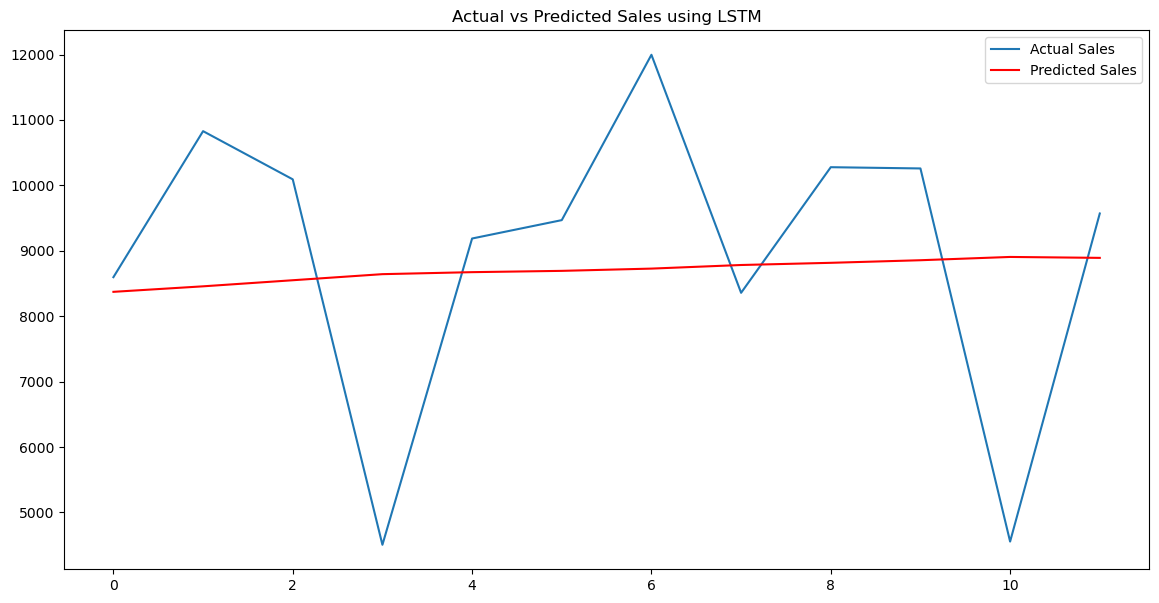

In [8]:
# Make predictions
predictions = model.predict(X_test)

# Inverse scale the predictions and actual values
predictions = scaler.inverse_transform(predictions)
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions vs actual values
plt.figure(figsize=(14, 7))
plt.plot(y_test_scaled, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using LSTM')
plt.legend()
plt.show()


### Hyperparameter Tuning Aproach:

* 1. Data Preparation
Use lagged sales as features, rescaling with MinMaxScaler or StandardScaler, and reshape the data into 3D arrays for LSTM input.

* 2. Train-Test Split
Similar to XGBoost, split the data sequentially.

* 3. Hyperparameter Tuning: Use a grid search or randomized search with a focus on the most impactful parameters.

In [9]:
%pip install keras -q

Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install scikeras -q

Note: you may need to restart the kernel to use updated packages.


In [22]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler

# Prepare data with lagged features and scale it
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define function for LSTM model creation
def create_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Wrap model for use with scikit-learn's grid search
model = KerasRegressor(build_fn=create_model, verbose=0)

# Define parameter grid
param_grid = {
    'units': [50, 100, 150],
    'dropout_rate': [0.1, 0.2, 0.3],
    'batch_size': [16, 32, 64],
    'epochs': [50, 100],
    'learning_rate': [0.001, 0.01],
}

# Perform random search
random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=param_grid,
                                   n_iter=10,
                                   scoring='neg_mean_squared_error')
random_search.fit(X_scaled, y_train)

# Retrieve the best parameters
best_params_lstm = random_search.best_params_
print('Best Parameters for LSTM:', best_params_lstm)


ModuleNotFoundError: No module named 'keras.wrappers'